In [18]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [19]:
news_df = pd.read_csv("../data/clean_news_dataset.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [20]:
print(news_df.shape)

news_df.head()

(44182, 7)


,title,text,subject,date,label,text_length,clean_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,1028,st century wire say ben stein reputable profes...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,4820,washington reuters u president donald trump re...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,1848,reuters puerto rico governor ricardo rossello ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,1244,monday donald trump embarrassed country accide...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,3137,glasgow scotland reuters u presidential candid...


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print(news_df.isnull().sum())

title          0
text           0
subject        0
date           0
label          0
text_length    0
clean_text     0
dtype: int64


In [23]:
news_df = news_df.dropna(subset=["clean_text"])

news_df = news_df.reset_index(drop=True)

print(news_df.shape)

(44182, 7)


In [24]:
X = news_df["clean_text"]

y = news_df["label"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 35345
Testing Samples  : 8837


In [26]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(35345, 5000)
(8837, 5000)


In [27]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.9876654973407265


In [28]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy :", nb_accuracy)

Naive Bayes Accuracy : 0.9281430349666177


In [29]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Linear SVM Accuracy :", svm_accuracy)

Linear SVM Accuracy : 0.9958130587303383


In [30]:
results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Naive Bayes",
            "Linear SVM",
        ],
        "Accuracy": [
            lr_accuracy,
            nb_accuracy,
            svm_accuracy,
        ],
    }
)

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
2,Linear SVM,0.995813
0,Logistic Regression,0.987665
1,Naive Bayes,0.928143


In [31]:
joblib.dump(svm_model, "../models/fake_news_model.pkl")

joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [32]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4554
           1       0.99      1.00      1.00      4283

    accuracy                           1.00      8837
   macro avg       1.00      1.00      1.00      8837
weighted avg       1.00      1.00      1.00      8837



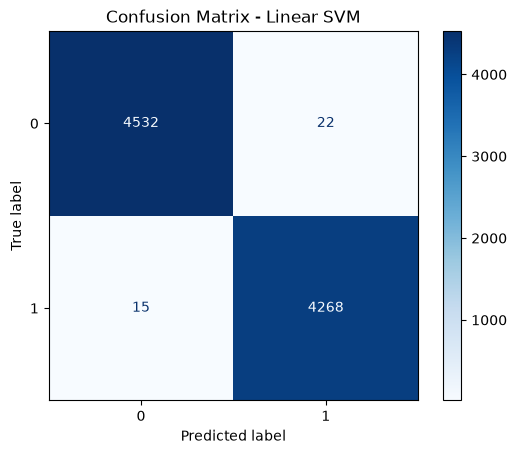

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [34]:
results.to_csv("../results/model_comparison.csv", index=False)

print("Comparison table saved successfully!")

Comparison table saved successfully!


In [35]:
from sklearn.metrics import accuracy_score

pred = best_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, pred))

NameError: name 'best_model' is not defined

In [36]:
import joblib

joblib.dump(svm_model, "../models/fake_news_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Saved successfully")

Saved successfully


In [38]:
sample = X_test.iloc[0]

print(sample[:300])
print("Actual:", y_test.iloc[0])

prediction = svm_model.predict(
    vectorizer.transform([sample])
)[0]

print("Predicted:", prediction)

kampala reuters fighting erupted uganda parliament second consecutive day wednesday plan change law extend president yoweri museveni rule east african country reuters witness said lawmaker opposed move also roughed ejected parliament chamber speaker rebecca kadaga suspended parliament misbehavior tu
Actual: 1
Predicted: 1


In [39]:
import joblib

loaded_model = joblib.load("../models/fake_news_model.pkl")
loaded_vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

prediction = loaded_model.predict(
    loaded_vectorizer.transform([sample])
)[0]

print("Actual:", y_test.iloc[0])
print("Predicted:", prediction)

Actual: 1
Predicted: 1


In [40]:
print(news_df["label"].value_counts())

print()

print(news_df[["label"]].head(20))

label
0    22766
1    21416
Name: count, dtype: int64

    label
0       0
1       1
2       1
3       0
4       1
5       0
6       0
7       0
8       1
9       1
10      1
11      1
12      1
13      0
14      1
15      0
16      0
17      0
18      1
19      0


In [41]:
print(news_df[["text", "label"]].head())

                                                text  label
0  21st Century Wire says Ben Stein, reputable pr...      0
1  WASHINGTON (Reuters) - U.S. President Donald T...      1
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...      1
3  On Monday, Donald Trump once again embarrassed...      0
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...      1


In [42]:
sample = news_df.iloc[0]["text"]

print("Actual Label:", news_df.iloc[0]["label"])

prediction = svm_model.predict(
    vectorizer.transform([sample])
)[0]

print("Predicted Label:", prediction)

Actual Label: 0
Predicted Label: 0


In [43]:
sample = news_df.iloc[1]["text"]

print("Actual Label:", news_df.iloc[1]["label"])

prediction = svm_model.predict(
    vectorizer.transform([sample])
)[0]

print("Predicted Label:", prediction)

Actual Label: 1
Predicted Label: 1
